# Modeling and Analysis on the Third Dataset
Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

Upload dataset

In [ ]:
Email = pd.read_csv('/content/Phishing_Email.csv')
Email.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


Create TF-IDF features and then run a Logistic Regression model on the dataset.

In [ ]:
X = Email['Email Text']
y = Email['Email Type']
vectorizer = TfidfVectorizer(stop_words='english',max_features = 1000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9490206600482962


In [ ]:
report = classification_report(y_test, y_pred)
print(report)

                precision    recall  f1-score   support

Phishing Email       0.91      0.97      0.94      1462
    Safe Email       0.98      0.94      0.96      2265

      accuracy                           0.95      3727
     macro avg       0.94      0.95      0.95      3727
  weighted avg       0.95      0.95      0.95      3727



In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.9455284316881947


Accuracy metrics are approximately 95%. The phishing f1 score is 94%, slightly less than for safe emails, 96%. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
logistic_regression = LogisticRegression(class_weight='balanced')
param_grid = {
    'C': [0.01, 0.1, 1, 10,100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'], # Regularization type (L1 or L2)
    'solver': ['liblinear', 'saga']     # Solvers that support both L1 and L2
}
grid_search = GridSearchCV(estimator=logistic_regression,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")
y_pred = best_model.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.9473
Test set accuracy with best model: 0.9528
                precision    recall  f1-score   support

Phishing Email       0.92      0.97      0.94      1462
    Safe Email       0.98      0.94      0.96      2265

      accuracy                           0.95      3727
     macro avg       0.95      0.96      0.95      3727
  weighted avg       0.95      0.95      0.95      3727



Some improvement in accuracy metrics. Phishing f1 score is still the same.Let's do KNN now.

In [ ]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_pca,y_train)
y_pred = knn_model.predict(X_test_pca)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.9254091762811913

In [ ]:
report = classification_report(y_test,y_pred)
print(report)

                precision    recall  f1-score   support

Phishing Email       0.89      0.92      0.91      1462
    Safe Email       0.95      0.93      0.94      2265

      accuracy                           0.93      3727
     macro avg       0.92      0.92      0.92      3727
  weighted avg       0.93      0.93      0.93      3727



In [ ]:
scores = cross_val_score(knn_model, X_train_pca, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.9242631231872955


Test accuracy and cross validation accuracy are approximately 92% while the phishing f1 score is 91%, somewhat less than the safe f1 score, 94%. Let's do hyperparameter tuning now.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_neighbors':np.arange(2,9)  # Number of neighbors (k)
}
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)


print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


best_knn = grid_search.best_estimator_


y_pred = best_knn.predict(X_test_pca)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the best KNN model on the test set: {accuracy:.4f}")

report = classification_report(y_test,y_pred)
print(report)

Best parameters: {'n_neighbors': np.int64(8)}
Best cross-validation score: 0.9245
Accuracy of the best KNN model on the test set: 0.9270
                precision    recall  f1-score   support

Phishing Email       0.88      0.94      0.91      1462
    Safe Email       0.96      0.92      0.94      2265

      accuracy                           0.93      3727
     macro avg       0.92      0.93      0.92      3727
  weighted avg       0.93      0.93      0.93      3727



Slight improvement in accuracy metrics. Phishing f1 score is still the same. Let's do Bernoulli Naive Bayes now.

In [ ]:
BN_model = BernoulliNB()
BN_model.fit(X_train,y_train)
y_pred = BN_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.8768446471693051


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

                precision    recall  f1-score   support

Phishing Email       0.77      0.97      0.86      1462
    Safe Email       0.98      0.81      0.89      2265

      accuracy                           0.88      3727
     macro avg       0.88      0.89      0.88      3727
  weighted avg       0.90      0.88      0.88      3727



In [ ]:
scores = cross_val_score(BN_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.8706644878777304


Test accuracy is approximately 88% while cross validation accuracy is approxiamtely 87%. The phishing f1 score is 86%, somewhat less than the safe f1 score, 89%.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics  import accuracy_score, classification_report
bnb = BernoulliNB()
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False] # Whether to learn class prior probabilities or assume uniform
}
grid_search = GridSearchCV(
    estimator=bnb,
    param_grid=param_grid,
    scoring='accuracy', # Metric to optimize (e.g., accuracy, f1, recall, etc.)
    cv=5,
    verbose=1,
    n_jobs=-1 # Use all available CPU cores
)
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy of the best model: {test_accuracy:.3f}")
report = classification_report(y_test,y_pred)
print(report)

Starting Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search complete.
Best parameters found: {'alpha': 0.01, 'fit_prior': True}
Best cross-validation accuracy: 0.873
Test accuracy of the best model: 0.878
                precision    recall  f1-score   support

Phishing Email       0.78      0.97      0.86      1462
    Safe Email       0.98      0.82      0.89      2265

      accuracy                           0.88      3727
     macro avg       0.88      0.89      0.88      3727
  weighted avg       0.90      0.88      0.88      3727



Slight improvement in accuracy metrics but no improvement in phishing f1 score. Let's do Decision Tree now.

In [ ]:
dt_model = DecisionTreeClassifier(class_weight = 'balanced')
dt_model.fit(X_train,y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9036758787228334


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

                precision    recall  f1-score   support

Phishing Email       0.86      0.90      0.88      1462
    Safe Email       0.93      0.91      0.92      2265

      accuracy                           0.90      3727
     macro avg       0.90      0.90      0.90      3727
  weighted avg       0.91      0.90      0.90      3727



In [ ]:
scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.913530135301353


Test accuracy is approximately 90% while cross valdiation accuracy is approximately 91%. The phishing f1 score is 88%, somewhat less than the safe f1 score, 92%. Let's do hyperparameter tuning now.

In [ ]:
X = Email['Email Text']
y = Email['Email Type']
vectorizer = TfidfVectorizer(stop_words='english',max_features = 1000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)
from sklearn.model_selection import GridSearchCV
import numpy as np
model = DecisionTreeClassifier(class_weight = 'balanced')
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(3, 15),
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best score achieved
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Get the best estimator (the Decision Tree model with the optimal hyperparameters)
best_dtree = grid_search.best_estimator_

# Evaluate the best model on the test set
test_accuracy = best_dtree.score(X_test, y_test)
print(f"Test set accuracy with best estimator: {test_accuracy:.4f}")

y_pred = best_dtree.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Best parameters: {'criterion': 'gini', 'max_depth': np.int64(14), 'min_samples_split': 2}
Best cross-validation score: 0.8709
Test set accuracy with best estimator: 0.8632
                precision    recall  f1-score   support

Phishing Email       0.75      0.97      0.85      1462
    Safe Email       0.98      0.80      0.88      2265

      accuracy                           0.86      3727
     macro avg       0.86      0.88      0.86      3727
  weighted avg       0.89      0.86      0.86      3727



No improvement in performance. Let's do Random Forest now.

In [ ]:
rf_model = RandomForestClassifier(class_weight = 'balanced')
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9522404078347196


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

                precision    recall  f1-score   support

Phishing Email       0.92      0.96      0.94      1462
    Safe Email       0.97      0.95      0.96      2265

      accuracy                           0.95      3727
     macro avg       0.95      0.95      0.95      3727
  weighted avg       0.95      0.95      0.95      3727



In [ ]:
scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.9526393517090466


Best performance so far. Accuracy metrics are approximately 95% while the f1 score for phishing emails is 94%, slightly less than the safe email f1 score, 96%. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}
grid_search = GridSearchCV(estimator= model,
                           param_grid=param_grid,
                           cv=5,                 # Number of cross-validation folds
                           n_jobs=-1,            # Use all available CPU cores
                           verbose=2,            # Display progress messages
                           scoring='accuracy')   # Metric to optimize

grid_search.fit(X_train, y_train)

print("Best parameters found by Grid Search:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
test_accuracy = best_rf_model.score(X_test, y_test)
print(f"\nAccuracy of the best model on the test set: {test_accuracy:.4f}")
y_pred = best_rf_model.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found by Grid Search:
{'bootstrap': False, 'max_depth': None, 'n_estimators': 200}

Best cross-validation score:
0.9550550760674973

Accuracy of the best model on the test set: 0.9525
                precision    recall  f1-score   support

Phishing Email       0.93      0.96      0.94      1462
    Safe Email       0.97      0.95      0.96      2265

      accuracy                           0.95      3727
     macro avg       0.95      0.95      0.95      3727
  weighted avg       0.95      0.95      0.95      3727



Some slight improvement in accuracy metrics. The phishing f1 score is still the same. Let's tabulate the results now.

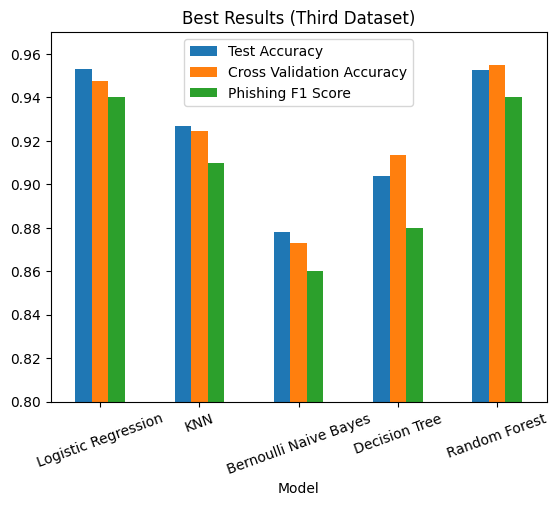

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
Table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Bernoulli Naive Bayes','Decision Tree','Random Forest'],
    'Test Accuracy' : [0.9528,0.9270, 0.878,0.9036758787228334,0.9525],
    'Cross Validation Accuracy' : [0.9473,0.9245,0.873,0.913530135301353,0.9550550760674973],
    'Phishing F1 Score': [0.94,0.91,0.86,0.88,0.94]
})
Table.set_index('Model',inplace=True)
Table.plot(kind="bar")
plt.title("Best Results (Third Dataset)")
plt.ylim([0.80,0.97])
plt.xticks(rotation=20)
plt.show()
